# *IT00CS34 Edge Computing for ML — Spring 26*



## Setup


In [1]:
! pip install --user --upgrade tensorflow-model-optimization


In [ ]:
import os
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import tensorflow_model_optimization as tfmot
import matplotlib.pyplot as plt
from tensorflow_model_optimization.python.core.keras.compat import keras

tf.random.set_seed(81)

print('TF version:', tf.__version__)


TF version: 2.20.0


## Data preprocessing 

In [ ]:
(dataset_train, dataset_val, dataset_test), ds_info = tfds.load(
    'rock_paper_scissors',
    split=['train[:90%]', 'train[90%:]', 'test'],
    shuffle_files=True,
    as_supervised=True,
    with_info=True,
)

batch_size = 32
n_epochs   = 8

def preprocess(image, label):
    image = tf.image.resize(image, (64, 64))
    image = tf.image.rgb_to_grayscale(image)
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

dataset_train = dataset_train.map(preprocess).shuffle(1000).batch(batch_size)
dataset_val   = dataset_val.map(preprocess).batch(batch_size)
dataset_test  = dataset_test.map(preprocess).batch(batch_size)

print('Train batches:', tf.data.experimental.cardinality(dataset_train).numpy())
print('Val   batches:', tf.data.experimental.cardinality(dataset_val).numpy())
print('Test  batches:', tf.data.experimental.cardinality(dataset_test).numpy())


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/2 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.RTKB0B_3.0.0/rock_paper_scissors-train.tfre…

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/rock_paper_scissors/incomplete.RTKB0B_3.0.0/rock_paper_scissors-test.tfrec…

Dataset rock_paper_scissors downloaded and prepared to /root/tensorflow_datasets/rock_paper_scissors/3.0.0. Subsequent calls will reuse this data.
Train batches: 71
Val   batches: 8
Test  batches: 12


## Section 1 — Base model 

In [ ]:
def build_base_model():
    m = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(64, 64, 1)),
        tf.keras.layers.Conv2D(8,  (3,3), strides=(2,2), activation='relu', padding='same'),
        tf.keras.layers.MaxPooling2D(2, 2),
        tf.keras.layers.Conv2D(16, (3,3), strides=(2,2), activation='relu', padding='same'),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(16, activation='relu'),
        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(3, activation='softmax'),
    ])
    m.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
    return m


BASE_MODEL_PATH = './Full_Precision_RPS.h5'

if os.path.exists(BASE_MODEL_PATH):

    model = keras.models.load_model(BASE_MODEL_PATH)
else:

    model = build_base_model()
    model.fit(
        dataset_train,
        validation_data=dataset_val,
        epochs=12,           
        verbose=1,
    )
    keras.models.save_model(model, BASE_MODEL_PATH, include_optimizer=False)
    print(f'Saved to {BASE_MODEL_PATH}')

model.summary()


No existing model found — training from scratch with the same architecture / seed / epochs as the main notebook.
Epoch 1/12
71/71 [==============================] - 14s 49ms/step - loss: 1.0630 - accuracy: 0.4546 - val_loss: 0.9913 - val_accuracy: 0.4960
Epoch 2/12
71/71 [==============================] - 4s 31ms/step - loss: 0.8795 - accuracy: 0.6213 - val_loss: 0.6972 - val_accuracy: 0.8452
Epoch 3/12
71/71 [==============================] - 5s 45ms/step - loss: 0.6006 - accuracy: 0.7720 - val_loss: 0.4740 - val_accuracy: 0.8532
Epoch 4/12
71/71 [==============================] - 4s 31ms/step - loss: 0.4136 - accuracy: 0.8391 - val_loss: 0.2611 - val_accuracy: 0.9484
Epoch 5/12
71/71 [==============================] - 7s 59ms/step - loss: 0.3156 - accuracy: 0.8743 - val_loss: 0.1887 - val_accuracy: 0.9841
Epoch 6/12
71/71 [==============================] - 5s 31ms/step - loss: 0.2500 - accuracy: 0.9034 - val_loss: 0.1355 - val_accuracy: 0.9921
Epoch 7/12
71/71 [======================

/tmp/ipykernel_4389/1882384067.py:35: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(model, BASE_MODEL_PATH, include_optimizer=False)


In [ ]:
_, baseline_accuracy = model.evaluate(dataset_test, verbose=0)
print(f'Baseline test accuracy: {baseline_accuracy:.4f}')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_baseline = converter.convert()
baseline_tflite_size = len(tflite_baseline)
print(f'Baseline TFLite size:  {baseline_tflite_size:,} bytes '
      f'({baseline_tflite_size/1024:.1f} KB)')


Baseline test accuracy: 0.7688
Baseline TFLite size:  73,960 bytes (72.2 KB)


## Section 2 — Pruning Comparison

* **Task 1A** — whole-model pruning
* **Task 1B** — conv-only pruning

Sparsities **0.3, 0.5, 0.7** 


In [ ]:
prune_low_magnitude = tfmot.sparsity.keras.prune_low_magnitude

num_train_batches = tf.data.experimental.cardinality(dataset_train).numpy()
end_step = int(num_train_batches) * n_epochs

configs = [
    ('whole',     0.3),
    ('whole',     0.5),
    ('whole',     0.7),
    ('conv_only', 0.3),
    ('conv_only', 0.5),
    ('conv_only', 0.7),
]

pruning_results   = {}     
best_pruned_acc   = -1.0
best_pruned_key   = None
best_pruned_model = None

for method, final_sparsity in configs:
    print(f'\n--- {method}, sparsity={final_sparsity} ---')

    schedule = tfmot.sparsity.keras.PolynomialDecay(
        initial_sparsity=0.0,
        final_sparsity=final_sparsity,
        begin_step=0,
        end_step=end_step,
    )

    base = keras.models.load_model(BASE_MODEL_PATH)

    if method == 'whole':
        pruned = prune_low_magnitude(base, pruning_schedule=schedule)
    else: 
        def _apply(layer):
            if isinstance(layer, tf.keras.layers.Conv2D):
                return prune_low_magnitude(layer, pruning_schedule=schedule)
            return layer
        pruned = keras.models.clone_model(base, clone_function=_apply)

    pruned.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy'],
    )
    pruned.fit(
        dataset_train,
        validation_data=dataset_val,
        epochs=n_epochs,
        callbacks=[tfmot.sparsity.keras.UpdatePruningStep()],
        verbose=0,
    )

    stripped = tfmot.sparsity.keras.strip_pruning(pruned)
    stripped.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])
    _, acc = stripped.evaluate(dataset_test, verbose=0)

    conv = tf.lite.TFLiteConverter.from_keras_model(stripped)
    tflite_bytes = conv.convert()
    tflite_size  = len(tflite_bytes)

    key = f'{method}_s{final_sparsity}'
    pruning_results[key] = {'acc': acc, 'tflite_size': tflite_size}
    print(f'  acc={acc:.4f}  tflite_size={tflite_size:,} bytes')

    if acc > best_pruned_acc:
        best_pruned_acc   = acc
        best_pruned_key   = key
        best_pruned_model = stripped

print(f'\nBest pruning config: {best_pruned_key}  (acc={best_pruned_acc:.4f})')
keras.models.save_model(best_pruned_model, './Pruned_Best.h5', include_optimizer=False)



--- whole, sparsity=0.3 ---


  acc=0.8011  tflite_size=73,960 bytes

--- whole, sparsity=0.5 ---


  acc=0.7151  tflite_size=73,960 bytes

--- whole, sparsity=0.7 ---


  acc=0.7796  tflite_size=73,960 bytes

--- conv_only, sparsity=0.3 ---


  acc=0.7769  tflite_size=73,960 bytes

--- conv_only, sparsity=0.5 ---


  acc=0.7742  tflite_size=73,960 bytes

--- conv_only, sparsity=0.7 ---
  acc=0.7151  tflite_size=73,960 bytes

Best pruning config: whole_s0.3  (acc=0.8011)


/tmp/ipykernel_4389/907655530.py:75: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native TF-Keras format, e.g. `model.save('my_model.keras')`.
  keras.models.save_model(best_pruned_model, './Pruned_Best.h5', include_optimizer=False)


In [7]:
print(f'Baseline (float32):  {baseline_tflite_size:,} bytes | acc={baseline_accuracy:.4f}\n')
print(f'{"Config":<20} {"Task":<6} {"Sparsity":>9} {"TFLite Size (B)":>17} {"Δ size":>9} {"Test Acc":>10}')
print('-' * 78)
for k, v in pruning_results.items():
    method, sparsity = k.rsplit('_s', 1)
    task   = '1A' if method == 'whole' else '1B'
    delta  = v['tflite_size'] - baseline_tflite_size
    print(f'{k:<20} {task:<6} {float(sparsity):>9.1f} '
          f'{v["tflite_size"]:>17,} {delta:>+9,} {v["acc"]:>10.4f}')


Baseline (float32):  73,960 bytes | acc=0.7688

Config               Task    Sparsity   TFLite Size (B)    Δ size   Test Acc
------------------------------------------------------------------------------
whole_s0.3           1A           0.3            73,960        +0     0.8011
whole_s0.5           1A           0.5            73,960        +0     0.7151
whole_s0.7           1A           0.7            73,960        +0     0.7796
conv_only_s0.3       1B           0.3            73,960        +0     0.7769
conv_only_s0.5       1B           0.5            73,960        +0     0.7742
conv_only_s0.7       1B           0.7            73,960        +0     0.7151


## Section 3 — Quantization Comparison




In [ ]:
def representative_data_gen():
    for img, _ in dataset_train.take(100):
        yield [img]


def evaluate_tflite(tflite_bytes, dataset):
    interp = tf.lite.Interpreter(model_content=tflite_bytes)
    interp.allocate_tensors()
    in_d  = interp.get_input_details()[0]
    out_d = interp.get_output_details()[0]
    in_scale, in_zp = in_d['quantization']

    correct, total = 0, 0
    for images, labels in dataset.unbatch().batch(1):
        img = images.numpy()
        if in_d['dtype'] == np.int8:
            img = (img / in_scale + in_zp).astype(np.int8)
        else:
            img = img.astype(in_d['dtype'])
        interp.set_tensor(in_d['index'], img)
        interp.invoke()
        pred = np.argmax(interp.get_tensor(out_d['index'])[0])
        correct += int(pred == labels.numpy()[0])
        total   += 1
    return correct / total


base = keras.models.load_model(BASE_MODEL_PATH)

# ── Task 2A — Dynamic-range quantization ────────────────────────────────────
conv_2a = tf.lite.TFLiteConverter.from_keras_model(base)
conv_2a.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_2a = conv_2a.convert()
acc_2a = evaluate_tflite(tflite_2a, dataset_test)
print(f'Task 2A (dynamic range)    size={len(tflite_2a):,} bytes  acc={acc_2a:.4f}')

# ── Task 2B — Integer weights, float I/O ────────────────────────────────────
conv_2b = tf.lite.TFLiteConverter.from_keras_model(base)
conv_2b.optimizations = [tf.lite.Optimize.DEFAULT]
conv_2b.representative_dataset = representative_data_gen
conv_2b.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
tflite_2b = conv_2b.convert()
acc_2b = evaluate_tflite(tflite_2b, dataset_test)
print(f'Task 2B (int8, float I/O)  size={len(tflite_2b):,} bytes  acc={acc_2b:.4f}')

# ── Task 2C — Full INT8 ─────────────────────────────────────────────────────
conv_2c = tf.lite.TFLiteConverter.from_keras_model(base)
conv_2c.optimizations = [tf.lite.Optimize.DEFAULT]
conv_2c.representative_dataset = representative_data_gen
conv_2c.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_2c.inference_input_type  = tf.int8
conv_2c.inference_output_type = tf.int8
tflite_2c = conv_2c.convert()
acc_2c = evaluate_tflite(tflite_2c, dataset_test)
print(f'Task 2C (full INT8)        size={len(tflite_2c):,} bytes  acc={acc_2c:.4f}')


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Task 2A (dynamic range)    size=21,712 bytes  acc=0.7661


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Task 2B (int8, float I/O)  size=22,744 bytes  acc=0.7688


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Task 2C (full INT8)        size=22,400 bytes  acc=0.7661


In [9]:
quant_results = [
    ('Baseline float32',          baseline_tflite_size, baseline_accuracy),
    ('Task 2A — Dynamic range',   len(tflite_2a),       acc_2a),
    ('Task 2B — Int8, float I/O', len(tflite_2b),       acc_2b),
    ('Task 2C — Full INT8',       len(tflite_2c),       acc_2c),
]

print(f'{"Model":<32} {"Size (bytes)":>14} {"Reduction":>11} {"Test Acc":>10}')
print('-' * 72)
for name, sz, acc in quant_results:
    reduction = (1 - sz / baseline_tflite_size) * 100
    print(f'{name:<32} {sz:>14,} {reduction:>10.1f}% {acc:>10.4f}')


Model                              Size (bytes)   Reduction   Test Acc
------------------------------------------------------------------------
Baseline float32                         73,960        0.0%     0.7688
Task 2A — Dynamic range                  21,712       70.6%     0.7661
Task 2B — Int8, float I/O                22,744       69.2%     0.7688
Task 2C — Full INT8                      22,400       69.7%     0.7661


> **Observation.** All three quantization methods achieve similar
> compression (~70% size reduction). **Full INT8 (Task 2C) is the only one
> fully supported by the Arduino Cortex-M runtime** — both inputs and outputs
> must be integer for the MCU's integer-only inference engine. Tasks 2A and 2B
> still keep float-format I/O, which the Arduino backend cannot run natively.
> That is why **Task 2C is the deployment choice** in the main notebook.


## Section 4 — Best Pruning + Full INT8 (the deployed model)



In [ ]:
pruned_best = keras.models.load_model('./Pruned_Best.h5')

conv_pq = tf.lite.TFLiteConverter.from_keras_model(pruned_best)
conv_pq.optimizations = [tf.lite.Optimize.DEFAULT]
conv_pq.representative_dataset = representative_data_gen
conv_pq.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
conv_pq.inference_input_type  = tf.int8
conv_pq.inference_output_type = tf.int8

tflite_pq = conv_pq.convert()

with open('./model_pruned_quant.tflite', 'wb') as f:
    f.write(tflite_pq)

acc_pq = evaluate_tflite(tflite_pq, dataset_test)

interp = tf.lite.Interpreter(model_content=tflite_pq)
print(f'Input  dtype: {interp.get_input_details()[0]["dtype"]}')
print(f'Output dtype: {interp.get_output_details()[0]["dtype"]}')
print(f'\nPruned + Full INT8 size: {len(tflite_pq):,} bytes  acc={acc_pq:.4f}')
print(f'Size reduction vs baseline: {(1 - len(tflite_pq)/baseline_tflite_size)*100:.1f}%')


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Input  dtype: <class 'numpy.int8'>
Output dtype: <class 'numpy.int8'>

Pruned + Full INT8 size: 22,400 bytes  acc=0.8011
Size reduction vs baseline: 69.7%


## Section 5 — Final Comparison Summary


In [11]:
all_results = [
    ('Baseline float32',                       baseline_tflite_size, baseline_accuracy),
    *[(f'Pruning {k}', v['tflite_size'], v['acc']) for k, v in pruning_results.items()],
    ('Quant 2A — Dynamic range',   len(tflite_2a), acc_2a),
    ('Quant 2B — Int8, float I/O', len(tflite_2b), acc_2b),
    ('Quant 2C — Full INT8',       len(tflite_2c), acc_2c),
    (f'Pruned ({best_pruned_key}) + Full INT8', len(tflite_pq), acc_pq),
]

print(f'{"Model":<44} {"Size (bytes)":>14} {"Reduction":>11} {"Test Acc":>10}')
print('=' * 84)
for name, sz, acc in all_results:
    reduction = (1 - sz / baseline_tflite_size) * 100
    marker = '  ← SELECTED (Arduino)' if ('Pruned' in name and 'INT8' in name and '+' in name) else ''
    print(f'{name:<44} {sz:>14,} {reduction:>10.1f}% {acc:>10.4f}{marker}')


Model                                          Size (bytes)   Reduction   Test Acc
Baseline float32                                     73,960        0.0%     0.7688
Pruning whole_s0.3                                   73,960        0.0%     0.8011
Pruning whole_s0.5                                   73,960        0.0%     0.7151
Pruning whole_s0.7                                   73,960        0.0%     0.7796
Pruning conv_only_s0.3                               73,960        0.0%     0.7769
Pruning conv_only_s0.5                               73,960        0.0%     0.7742
Pruning conv_only_s0.7                               73,960        0.0%     0.7151
Quant 2A — Dynamic range                             21,712       70.6%     0.7661
Quant 2B — Int8, float I/O                           22,744       69.2%     0.7688
Quant 2C — Full INT8                                 22,400       69.7%     0.7661
Pruned (whole_s0.3) + Full INT8                      22,400       69.7%     0.8011  ← S

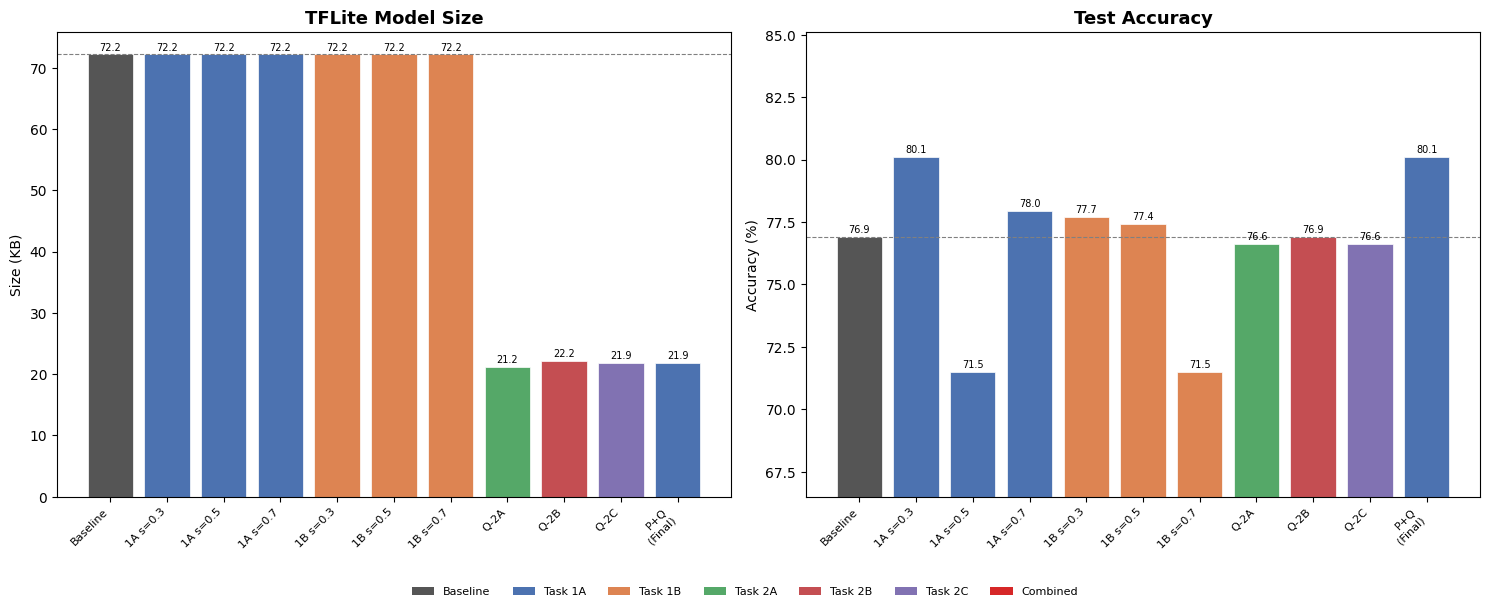

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

colors = {
    'Baseline':    '#555555',
    'Task 1A':     '#4C72B0',
    'Task 1B':     '#DD8452',
    'Task 2A':     '#55A868',
    'Task 2B':     '#C44E52',
    'Task 2C':     '#8172B2',
    'Combined':    '#D62728',
}

def cat(name):
    if 'Baseline'  in name: return 'Baseline'
    if 'whole_s'   in name: return 'Task 1A'
    if 'conv_only' in name and 'INT8' not in name: return 'Task 1B'
    if '2A' in name: return 'Task 2A'
    if '2B' in name: return 'Task 2B'
    if '2C' in name: return 'Task 2C'
    return 'Combined'

short_labels = [
    'Baseline',
    '1A s=0.3', '1A s=0.5', '1A s=0.7',
    '1B s=0.3', '1B s=0.5', '1B s=0.7',
    'Q-2A', 'Q-2B', 'Q-2C',
    'P+Q\n(Final)',
]

labels, sizes, accs, bar_colors = [], [], [], []
for (name, sz, acc), short in zip(all_results, short_labels):
    labels.append(short)
    sizes.append(sz / 1024)   # KB
    accs.append(acc * 100)    # %
    bar_colors.append(colors[cat(name)])

x = range(len(labels))

bars1 = axes[0].bar(x, sizes, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('TFLite Model Size', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Size (KB)')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
axes[0].axhline(sizes[0], color='grey', linestyle='--', linewidth=0.8, label='Baseline')
for bar, val in zip(bars1, sizes):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=7)

bars2 = axes[1].bar(x, accs, color=bar_colors, edgecolor='white', linewidth=0.5)
axes[1].set_title('Test Accuracy', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
acc_min = max(0, min(accs) - 5)
acc_max = min(100, max(accs) + 5)
axes[1].set_ylim(acc_min, acc_max)
axes[1].axhline(accs[0], color='grey', linestyle='--', linewidth=0.8, label='Baseline')
for bar, val in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'{val:.1f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors.items()]
fig.legend(handles=legend_elements, loc='lower center', ncol=7,
           fontsize=8, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig('compression_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
